https://data.cityofnewyork.us/Transportation/Street-Pavement-Rating/6yyb-pb25/about_data
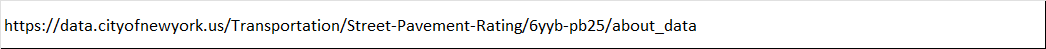
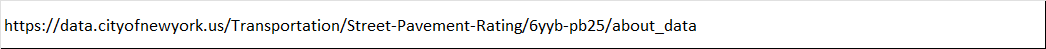
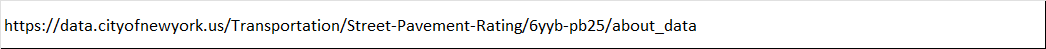
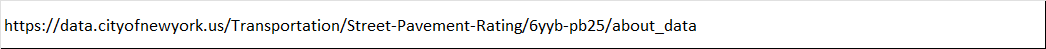

In [1]:
# Import necessary libraries for geospatial data processing.
import geopandas as gpd  # For geospatial data operations (GeoJSON, spatial joins, etc.).
import pandas as pd  # For handling tabular data (CSV files).
import shapely  # Import shapely explicitly to access its version.
from shapely.geometry import Point  # For creating Point geometries from coordinates.
import sys  # For accessing the Python version.

# Debug: Confirm that imports are successful.
print("Debug: Libraries imported successfully.")

# Print the versions of Python and each imported module.
print(f"Python version: {sys.version}")
print(f"pandas version: {pd.__version__}")
print(f"geopandas version: {gpd.__version__}")
print(f"shapely version: {shapely.__version__}")

# Define directory paths for Kaggle environment.
base_dir = r"/kaggle/input/eyds-base-dataset"  # Base directory for input datasets.
sub_dir = r"/kaggle/working/"  # Submission directory for output files.

# Define file paths for input datasets.
# Note: The shapefile and its associated files (.shx, .dbf, etc.) should be in a subdirectory.
street_shp_path = f"{base_dir}/StreetAssessmentRating/StreetAssessmentRating.shp" 
#https://data.cityofnewyork.us/Transportation/Street-Pavement-Rating/6yyb-pb25/about_data

train_file = f"{base_dir}/Training_data.csv"
valid_file = f"{base_dir}/Validation_data.csv"

# Define output file paths for joined datasets.
output_train_csv = f"{sub_dir}/joined_training.csv"
output_valid_csv = f"{sub_dir}/joined_validation.csv"

# Debug: Print the file paths to confirm they are set correctly.
print(f"Debug: Street shapefile path: {street_shp_path}")
print(f"Debug: Training file path: {train_file}")
print(f"Debug: Validation file path: {valid_file}")
print(f"Debug: Output training CSV path: {output_train_csv}")
print(f"Debug: Output validation CSV path: {output_valid_csv}")

Debug: Libraries imported successfully.
Python version: 3.10.12 (main, Nov  6 2024, 20:22:13) [GCC 11.4.0]
pandas version: 2.2.3
geopandas version: 0.14.4
shapely version: 2.0.7
Debug: Street shapefile path: /kaggle/input/eyds-base-dataset/StreetAssessmentRating/StreetAssessmentRating.shp
Debug: Training file path: /kaggle/input/eyds-base-dataset/Training_data.csv
Debug: Validation file path: /kaggle/input/eyds-base-dataset/Validation_data.csv
Debug: Output training CSV path: /kaggle/working//joined_training.csv
Debug: Output validation CSV path: /kaggle/working//joined_validation.csv


In [2]:
# --- Step 1: Load the line shapefile (street assessment data) ---
print("Loading street assessment shapefile...")
try:
    street_gdf = gpd.read_file(street_shp_path)
except Exception as e:
    print(f"Error: Failed to load street shapefile at {street_shp_path}. Error: {str(e)}")
   

# Debug: Print the shape, CRS, and columns of the street GeoDataFrame.
print(f"Debug: Street GeoDataFrame shape: {street_gdf.shape}")
print(f"Debug: Street GeoDataFrame CRS: {street_gdf.crs}")
print(f"Debug: Street GeoDataFrame columns: {street_gdf.columns.tolist()}")

Loading street assessment shapefile...
Debug: Street GeoDataFrame shape: (81209, 10)
Debug: Street GeoDataFrame CRS: EPSG:2263
Debug: Street GeoDataFrame columns: ['SegmentID', 'Length', 'Width', 'UsageClass', 'Rating_B', 'RatingWord', 'RatingDate', 'RatingFY_S', 'Shape_len', 'geometry']


In [3]:
# --- Step 2: Load the CSVs and convert to GeoDataFrames ---
# Load the training dataset.
print("Loading dataset...")
training_df = pd.read_csv(train_file)

# Debug: Print the shape and columns of the training DataFrame.
print(f"Debug: Training DataFrame shape: {training_df.shape}")
print(f"Debug: Training DataFrame columns: {training_df.columns.tolist()}")

# Load the validation dataset.
validation_df = pd.read_csv(valid_file)

# Debug: Print the shape and columns of the validation DataFrame.
print(f"Debug: Validation DataFrame shape: {validation_df.shape}")
print(f"Debug: Validation DataFrame columns: {validation_df.columns.tolist()}")

# Convert the training DataFrame to a GeoDataFrame with Point geometries.
training_gdf = gpd.GeoDataFrame(
    training_df, 
    geometry=[Point(xy) for xy in zip(training_df['Longitude'], training_df['Latitude'])],
    crs="EPSG:4326"
)

# Debug: Print the shape, CRS, and geometry type of the training GeoDataFrame.
print(f"Debug: Training GeoDataFrame shape: {training_gdf.shape}")
print(f"Debug: Training GeoDataFrame CRS: {training_gdf.crs}")
print(f"Debug: Training GeoDataFrame geometry type: {training_gdf.geometry.type[0]}")

# Convert the validation DataFrame to a GeoDataFrame with Point geometries.
validation_gdf = gpd.GeoDataFrame(
    validation_df, 
    geometry=[Point(xy) for xy in zip(validation_df['Longitude'], validation_df['Latitude'])],
    crs="EPSG:4326"
)

# Debug: Print the shape, CRS, and geometry type of the validation GeoDataFrame.
print(f"Debug: Validation GeoDataFrame shape: {validation_gdf.shape}")
print(f"Debug: Validation GeoDataFrame CRS: {validation_gdf.crs}")
print(f"Debug: Validation GeoDataFrame geometry type: {validation_gdf.geometry.type[0]}")

Loading dataset...
Debug: Training DataFrame shape: (11229, 4)
Debug: Training DataFrame columns: ['Longitude', 'Latitude', 'datetime', 'UHI Index']
Debug: Validation DataFrame shape: (1040, 3)
Debug: Validation DataFrame columns: ['Longitude', 'Latitude', 'UHI Index']
Debug: Training GeoDataFrame shape: (11229, 5)
Debug: Training GeoDataFrame CRS: EPSG:4326
Debug: Training GeoDataFrame geometry type: Point
Debug: Validation GeoDataFrame shape: (1040, 4)
Debug: Validation GeoDataFrame CRS: EPSG:4326
Debug: Validation GeoDataFrame geometry type: Point


In [4]:
# --- Step 3: Ensure both datasets share the same CRS ---
# Check if the street GeoDataFrame's CRS matches EPSG:4326; if not, reproject it.
if street_gdf.crs != "EPSG:4326":
    print("Debug: Reprojecting street GeoDataFrame to EPSG:4326...")
    street_gdf = street_gdf.to_crs("EPSG:4326")
else:
    print("Debug: Street GeoDataFrame already in EPSG:4326.")

# Debug: Confirm the CRS after checking/reprojecting.
print(f"Debug: Street GeoDataFrame CRS after reprojection: {street_gdf.crs}")

# --- Step 4: Use sjoin_nearest to match each point to the closest street line ---
# Perform a nearest-neighbor spatial join for the training GeoDataFrame.
print("Performing nearest-neighbor spatial join for training data...")
joined_training = gpd.sjoin_nearest(training_gdf, street_gdf, how="left")

# Debug: Print the shape and columns of the joined training GeoDataFrame.
print(f"Debug: Joined Training GeoDataFrame shape: {joined_training.shape}")
print(f"Debug: Joined Training GeoDataFrame columns: {joined_training.columns.tolist()}")

# Perform a nearest-neighbor spatial join for the validation GeoDataFrame.
print("Performing nearest-neighbor spatial join for validation data...")
joined_validation = gpd.sjoin_nearest(validation_gdf, street_gdf, how="left")

# Debug: Print the shape and columns of the joined validation GeoDataFrame.
print(f"Debug: Joined Validation GeoDataFrame shape: {joined_validation.shape}")
print(f"Debug: Joined Validation GeoDataFrame columns: {joined_validation.columns.tolist()}")

Debug: Reprojecting street GeoDataFrame to EPSG:4326...
Debug: Street GeoDataFrame CRS after reprojection: EPSG:4326
Performing nearest-neighbor spatial join for training data...


/usr/local/lib/python3.10/dist-packages/geopandas/array.py:365: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


Debug: Joined Training GeoDataFrame shape: (11466, 15)
Debug: Joined Training GeoDataFrame columns: ['Longitude', 'Latitude', 'datetime', 'UHI Index', 'geometry', 'index_right', 'SegmentID', 'Length', 'Width', 'UsageClass', 'Rating_B', 'RatingWord', 'RatingDate', 'RatingFY_S', 'Shape_len']
Performing nearest-neighbor spatial join for validation data...
Debug: Joined Validation GeoDataFrame shape: (1059, 14)
Debug: Joined Validation GeoDataFrame columns: ['Longitude', 'Latitude', 'UHI Index', 'geometry', 'index_right', 'SegmentID', 'Length', 'Width', 'UsageClass', 'Rating_B', 'RatingWord', 'RatingDate', 'RatingFY_S', 'Shape_len']


/usr/local/lib/python3.10/dist-packages/geopandas/array.py:365: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


In [5]:
# --- Step 5: Save outputs to CSV ---
print("Saving joined datasets to CSV...")
joined_training.to_csv(output_train_csv, index=False)
joined_validation.to_csv(output_valid_csv, index=False)

# Debug: Print the final confirmation messages with file paths.
print(f"Debug: Joined training data saved to: {output_train_csv}")
print(f"Debug: Joined validation data saved to: {output_valid_csv}")

print("Nearest-neighbor join completed; output CSV files saved.")

Saving joined datasets to CSV...
Debug: Joined training data saved to: /kaggle/working//joined_training.csv
Debug: Joined validation data saved to: /kaggle/working//joined_validation.csv
Nearest-neighbor join completed; output CSV files saved.
